# Notebook 03 - Product Description Evaluation

## Objective

This notebook evaluates the quality of the product descriptions generated in Notebook 02.
We compare 3 generation styles (short, marketing, technical) against the original Amazon
reference descriptions using 3 complementary metrics:

- **BLEU** : measures n-gram overlap between the generated and reference text
- **ROUGE-L** : measures the longest common subsequence between both texts
- **Cosine Similarity** : measures semantic proximity via sentence embeddings

These metrics are complementary by design — BLEU and ROUGE capture lexical overlap,
while cosine similarity captures meaning regardless of exact wording.

The goal is to identify which style best approximates the original Amazon descriptions,
and use it as the training target for LoRA fine-tuning in Notebook 04.

In [1]:
!pip install rouge-score sentence-transformers -q

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import drive
drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


## 1 - Load data

In [2]:
# Load generated dataset
df_generated = pd.read_json("/content/drive/MyDrive/dataset.jsonl", lines=True)
print("Duplicates in generated dataset:", df_generated.duplicated(subset="title").sum())

# Load original dataset with reference descriptions
df_original = pd.read_csv("clean_products_800.csv")[["title", "description"]]
print("Duplicates in original dataset:", df_original.duplicated(subset="title").sum())

# Merge on title
df = df_generated.merge(df_original, on="title", how="left")

print(f"\nFinal shape      : {df.shape}")
print(f"Missing references: {df['description'].isna().sum()}")

Duplicates in generated dataset: 0
Duplicates in original dataset: 0

Final shape      : (800, 8)
Missing references: 0


## 2 - BLEU & ROUGE-L

BLEU and ROUGE-L are standard NLP metrics for evaluating text generation quality.

- **BLEU** was originally designed for machine translation. It measures the precision of n-gram matches between hypothesis and reference. We apply `SmoothingFunction().method4` to avoid zero scores on short texts with no exact matches.

- **ROUGE-L** was designed for automatic summarization. It measures the F1-score of the longest common subsequence (LCS). We use `use_stemmer=True` to normalize word forms before comparison (e.g. "running" → "run").

> Note: Both metrics are purely lexical. Two semantically identical sentences using different words will score low. This is why we complement them with cosine similarity.

**BLEU:**

| Score range | Interpretation |
|---|---|
| > 0.40 | Good, close to human-level |
| 0.20 – 0.40 | Acceptable, used in machine translation |
| 0.10 – 0.20 | Low but acceptable for free generation |
| < 0.10 | Very low, little lexical overlap |

**ROUGE-L:**

| Score range | Interpretation |
|---|---|
| > 0.50 | Very good, used in summarization |
| 0.30 – 0.50 | Good, common in summarization tasks |
| 0.15 – 0.30 | Acceptable for free generation |
| < 0.15 | Low, little common subsequence |

In [3]:
# BLEU
def compute_bleu(reference, hypothesis):
    ref_tokens = nltk.word_tokenize(reference.lower())
    hyp_tokens = nltk.word_tokenize(hypothesis.lower())
    smoothie = SmoothingFunction().method4
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)

# ROUGE-L — scorer instantiated once outside the function for efficiency
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge(reference, hypothesis):
    score = scorer.score(reference, hypothesis)
    return score["rougeL"].fmeasure

In [4]:
results = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    if pd.isna(row["description"]):
        continue

    ref = row["description"]

    results.append({
        "title": row["title"],
        "bleu_short":        compute_bleu(ref, row["short_description"]),
        "bleu_marketing":    compute_bleu(ref, row["marketing_description"]),
        "bleu_technical":    compute_bleu(ref, row["technical_description"]),
        "rouge_short":       compute_rouge(ref, row["short_description"]),
        "rouge_marketing":   compute_rouge(ref, row["marketing_description"]),
        "rouge_technical":   compute_rouge(ref, row["technical_description"]),
    })

df_scores = pd.DataFrame(results)
print(df_scores[["bleu_short", "bleu_marketing", "bleu_technical",
                  "rouge_short", "rouge_marketing", "rouge_technical"]].describe())

  0%|          | 0/800 [00:00<?, ?it/s]

       bleu_short  bleu_marketing  bleu_technical  rouge_short  \
count  800.000000      800.000000      800.000000   800.000000   
mean     0.023921        0.021087        0.022950     0.171799   
std      0.042577        0.024720        0.032285     0.102034   
min      0.000000        0.000000        0.000000     0.000000   
25%      0.001959        0.007089        0.005547     0.105138   
50%      0.008973        0.013359        0.012737     0.144456   
75%      0.024231        0.024256        0.025172     0.205128   
max      0.445285        0.221040        0.258489     0.692308   

       rouge_marketing  rouge_technical  
count       800.000000       800.000000  
mean          0.140442         0.165865  
std           0.055564         0.079340  
min           0.000000         0.000000  
25%           0.106269         0.114286  
50%           0.134723         0.150000  
75%           0.169492         0.202899  
max           0.509434         0.629630  


## 3 - Semantic Similarity (Cosine)

Cosine similarity measures the angle between two sentence embedding vectors.
A score of 1.0 means identical direction (semantically equivalent), 0 means
orthogonal (unrelated).

We use `all-MiniLM-L6-v2`, a lightweight (~80MB) but highly performant
sentence-transformer model, standard for semantic similarity tasks.

Embeddings are computed in batches of 64 for efficiency. Each description is
encoded into a 384-dimensional vector, then compared pairwise with the reference.

**Cosine Similarity:**

| Score range | Interpretation |
|---|---|
| > 0.85 | Very close semantically |
| 0.70 – 0.85 | Similar, same topic treated similarly |
| 0.50 – 0.70 | Same topic, different treatment |
| < 0.50 | Little semantic overlap |

In [5]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

refs       = df["description"].fillna("").tolist()
shorts     = df["short_description"].tolist()
marketings = df["marketing_description"].tolist()
technicals = df["technical_description"].tolist()

print("Computing embeddings...")
emb_ref       = embedder.encode(refs,       batch_size=64, show_progress_bar=True)
emb_short     = embedder.encode(shorts,     batch_size=64, show_progress_bar=True)
emb_marketing = embedder.encode(marketings, batch_size=64, show_progress_bar=True)
emb_technical = embedder.encode(technicals, batch_size=64, show_progress_bar=True)

cos_short     = [cosine_similarity([emb_ref[i]], [emb_short[i]])[0][0]     for i in range(len(refs))]
cos_marketing = [cosine_similarity([emb_ref[i]], [emb_marketing[i]])[0][0] for i in range(len(refs))]
cos_technical = [cosine_similarity([emb_ref[i]], [emb_technical[i]])[0][0] for i in range(len(refs))]

df_scores["cosine_short"]     = cos_short
df_scores["cosine_marketing"] = cos_marketing
df_scores["cosine_technical"] = cos_technical

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Computing embeddings...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [6]:
print(df_scores[["cosine_short", "cosine_marketing", "cosine_technical"]].describe())

       cosine_short  cosine_marketing  cosine_technical
count    800.000000        800.000000        800.000000
mean       0.621377          0.620498          0.639208
std        0.150460          0.151405          0.149307
min       -0.022937          0.026415         -0.001726
25%        0.525838          0.529607          0.546237
50%        0.645659          0.639041          0.657375
75%        0.732790          0.729640          0.749357
max        0.913289          0.908886          0.921708


## 4 - Composite Score

Raw metrics are not directly comparable: BLEU typically ranges 0.01–0.15 for
free generation, while cosine similarity ranges 0.50–0.90. Averaging them directly would give cosine disproportionate weight due to its higher absolute values.

**We apply min-max normalization** to bring all metrics to the [0, 1] range before combining them.

**Weighting rationale:**
- Cosine similarity receives 50% weight — it is the most robust metric for this task, capturing semantic alignment regardless of exact wording.
- BLEU and ROUGE-L each receive 25% — they add signal on lexical overlap but are less adapted to free-form generation from sparse input.

In [7]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

for style in ["short", "marketing", "technical"]:
    df_scores[f"bleu_{style}_norm"]   = normalize(df_scores[f"bleu_{style}"])
    df_scores[f"rouge_{style}_norm"]  = normalize(df_scores[f"rouge_{style}"])
    df_scores[f"cosine_{style}_norm"] = normalize(df_scores[f"cosine_{style}"])

weights = {"bleu": 0.25, "rouge": 0.25, "cosine": 0.50}

for style in ["short", "marketing", "technical"]:
    df_scores[f"score_{style}"] = (
        weights["bleu"]   * df_scores[f"bleu_{style}_norm"]   +
        weights["rouge"]  * df_scores[f"rouge_{style}_norm"]  +
        weights["cosine"] * df_scores[f"cosine_{style}_norm"]
    )

print("=== MEAN COMPOSITE SCORES BY STYLE ===")
for style in ["short", "marketing", "technical"]:
    print(f"  {style:12} → {df_scores[f'score_{style}'].mean():.4f}")

=== MEAN COMPOSITE SCORES BY STYLE ===
  short        → 0.4196
  marketing    → 0.4294
  technical    → 0.4351


## 5 - Visualizations

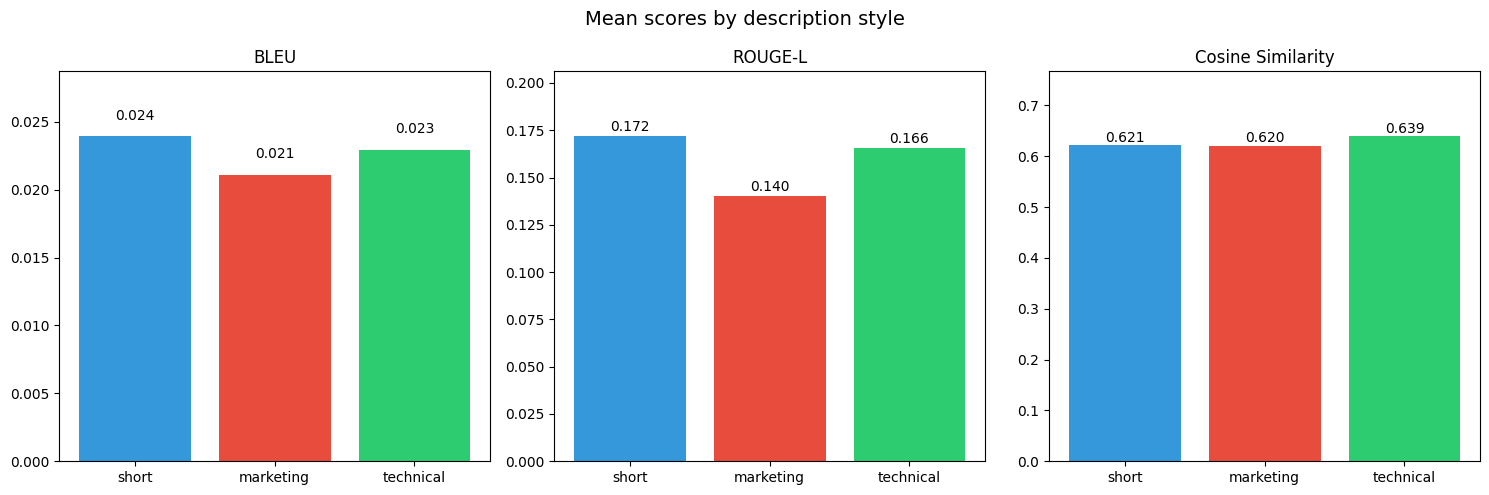

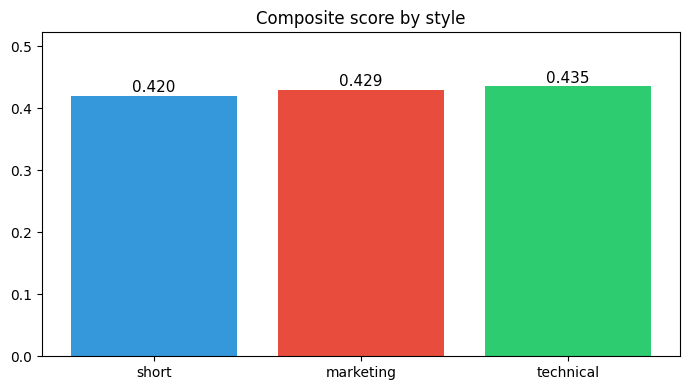

In [8]:
styles = ["short", "marketing", "technical"]
metrics = ["bleu", "rouge", "cosine"]
metric_titles = ["BLEU", "ROUGE-L", "Cosine Similarity"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Mean scores by description style", fontsize=14)

for ax, metric, title in zip(axes, metrics, metric_titles):
    means = [df_scores[f"{metric}_{style}"].mean() for style in styles]
    bars = ax.bar(styles, means, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, max(means) * 1.2)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("scores_by_style.png", dpi=150)
plt.show()

# Composite score
fig, ax = plt.subplots(figsize=(7, 4))
means = [df_scores[f"score_{style}"].mean() for style in styles]
bars = ax.bar(styles, means, color=colors)
ax.set_title("Composite score by style")
ax.set_ylim(0, max(means) * 1.2)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("composite_score.png", dpi=150)
plt.show()

/tmp/ipykernel_567/3110206905.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=styles, patch_artist=True)
/tmp/ipykernel_567/3110206905.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=styles, patch_artist=True)
/tmp/ipykernel_567/3110206905.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=styles, patch_artist=True)


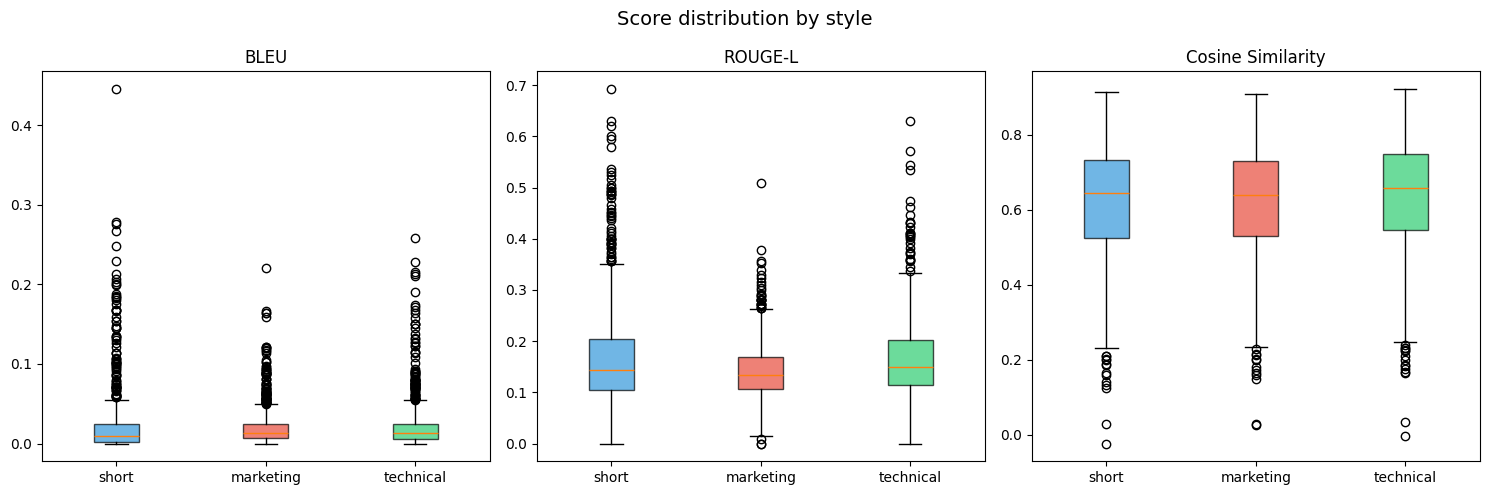

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Score distribution by style", fontsize=14)

for ax, metric, title in zip(axes, metrics, metric_titles):
    data = [df_scores[f"{metric}_{style}"] for style in styles]
    bp = ax.boxplot(data, labels=styles, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150)
plt.show()

## 6 - Qualitative Analysis

Beyond automatic metrics, manual inspection of best and worst scoring examples
is essential to validate that scores reflect actual generation quality.

In [10]:
print("=" * 70)
print("TOP 3 - HIGHEST TECHNICAL SCORES")
print("=" * 70)
top3 = df_scores.nlargest(3, "score_technical")[["title", "score_technical"]]

for _, row in top3.iterrows():
    original  = df[df["title"] == row["title"]]["description"].values[0]
    technical = df[df["title"] == row["title"]]["technical_description"].values[0]
    print(f"\nProduct   : {row['title'][:70]}...")
    print(f"Score     : {row['score_technical']:.3f}")
    print(f"Reference : {original[:200]}...")
    print(f"Generated : {technical[:200]}...")

print("\n" + "=" * 70)
print("TOP 3 - LOWEST TECHNICAL SCORES")
print("=" * 70)
bot3 = df_scores.nsmallest(3, "score_technical")[["title", "score_technical"]]

for _, row in bot3.iterrows():
    original  = df[df["title"] == row["title"]]["description"].values[0]
    technical = df[df["title"] == row["title"]]["technical_description"].values[0]
    print(f"\nProduct   : {row['title'][:70]}...")
    print(f"Score     : {row['score_technical']:.3f}")
    print(f"Reference : {original[:200]}...")
    print(f"Generated : {technical[:200]}...")

TOP 3 - HIGHEST TECHNICAL SCORES

Product   : Professional Kingston MicroSDHC 32GB (32 Gigabyte) Card for Nokia Lumi...
Score     : 0.861
Reference : Professional Kingston MicroSDHC 32GB (32 Gigabyte) Card for Nokia Lumia 822 with custom formatting and Standard SD Adapter. (SDHC Class 4 Certified)...
Generated : The Kingston Professional SDHC 32GB microSD card, priced at $9.50, is compatible with the Nokia Lumia 822 phone. This card comes with custom formatting and includes a standard SD adapter. It carries t...

Product   : eForCity?Black Faux PU Standing Case Pouch with FREE Anti-Glare Matte ...
Score     : 0.828
Reference : eForCity?Black Faux PU Standing Case Pouch with FREE Anti-Glare Matte LCD Matte Cover compatible with Amazon Kindle Fire / The New Kindle Fire...
Generated : The Live2Pedal eForCity?Black Faux PU Standing Case Pouch is a protective cover designed for Amazon Kindle Fire and The New Kindle Fire tablets. It features a durable, lightweight construction with a ...

Pr

### Observation

Inspecting the lowest-scoring examples reveals that poor scores are not
always caused by poor generation quality. In several cases, the original
Amazon description is not a proper product description at all:

- **Logistic text**: "Shipping options: Delivery time 14-20 days..."
- **Compatibility lists**: long lists of compatible device model numbers
- **Generic marketing boilerplate**: "This Factory Direct product is from the actual manufacturer..."

In these cases, the generated technical description is factually correct
and well-structured, but scores low simply because the reference provides
no meaningful signal to compare against.

This highlights a fundamental limitation of reference-based metrics:
**their quality is bounded by the quality of the reference data.**

## 7 - Conclusion

In [11]:
best_style = max(styles, key=lambda s: df_scores[f"score_{s}"].mean())

print("=" * 50)
print("EVALUATION SUMMARY")
print("=" * 50)
print(f"\nBest style : {best_style.upper()}")
print(f"\nMean scores:")
print(f"  {'':12} {'SHORT':>8} {'MARKETING':>10} {'TECHNICAL':>10}")
print(f"  {'BLEU':12} {df_scores['bleu_short'].mean():>8.3f} {df_scores['bleu_marketing'].mean():>10.3f} {df_scores['bleu_technical'].mean():>10.3f}")
print(f"  {'ROUGE-L':12} {df_scores['rouge_short'].mean():>8.3f} {df_scores['rouge_marketing'].mean():>10.3f} {df_scores['rouge_technical'].mean():>10.3f}")
print(f"  {'Cosine':12} {df_scores['cosine_short'].mean():>8.3f} {df_scores['cosine_marketing'].mean():>10.3f} {df_scores['cosine_technical'].mean():>10.3f}")
print(f"  {'Composite':12} {df_scores['score_short'].mean():>8.3f} {df_scores['score_marketing'].mean():>10.3f} {df_scores['score_technical'].mean():>10.3f}")
print(f"\n→ The '{best_style}' style will be used as training target for LoRA fine-tuning.")

df_scores.to_csv("/content/drive/MyDrive/scores_evaluation.csv", index=False)
print("\nScores exported to Google Drive.")

EVALUATION SUMMARY

Best style : TECHNICAL

Mean scores:
                  SHORT  MARKETING  TECHNICAL
  BLEU            0.024      0.021      0.023
  ROUGE-L         0.172      0.140      0.166
  Cosine          0.621      0.620      0.639
  Composite       0.420      0.429      0.435

→ The 'technical' style will be used as training target for LoRA fine-tuning.

Scores exported to Google Drive.


### Key Findings

**BLEU scores are low (0.021–0.024)** across all styles. This is expected:
BLEU was designed for machine translation where hypothesis and reference
should be near-identical. For free-form generation from sparse metadata,
scores in this range are consistent with the literature.

**ROUGE-L scores (0.14–0.17)** place our results at the lower bound of
acceptable range for generative tasks. The marketing style scores lower
than short and technical, which is consistent with its more creative
vocabulary diverging from the factual Amazon reference style.

**Cosine similarity (0.62–0.64)** is the most informative metric here.
Scores in the 0.50–0.70 range indicate that generated descriptions cover
the same product topic but with a different treatment — expected given
the sparse input (title, brand, category, price only).

**The technical style wins on all three metrics**, with a composite score
of 0.435 vs 0.420 for short and 0.429 for marketing. While the margin
is narrow (~0.015), the result is consistent across BLEU, ROUGE-L and
cosine, which strengthens the conclusion.

### Limitations

- Scores are bounded by reference quality. A significant portion of Amazon
  original descriptions are not proper product descriptions (logistic text,
  compatibility lists, generic boilerplate), which artificially lowers scores
  for those products regardless of generation quality.
- With only 4 input fields (title, brand, category, price), the model cannot
  reproduce the level of detail present in human-written Amazon descriptions.
  Richer input features would likely improve all metrics significantly.
- These metrics measure proximity to Amazon's writing style, not absolute
  description quality. A human evaluation on a sample of 20–30 products
  would complement these findings.

### Next Step

The **technical style** descriptions will be used as training targets in
**Notebook 04 — LoRA Fine-tuning**, where we will train Mistral 7B to
directly generate technical descriptions from product metadata.
Post fine-tuning scores will be compared against these baselines to
measure improvement.